In [1]:
import os
import rasterio
import rioxarray as rxr
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import glob
from pathlib import Path
from rasterio.warp import reproject, Resampling
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from rasterstats import zonal_stats
import geopandas as gpd
from metloom.pointdata import SnotelPointData
from datetime import datetime
from osgeo import gdal
from shapely.geometry import Point
from pyproj import Proj, Transformer

from scripts.Model_prep import flattened

gdal.UseExceptions()
from matplotlib.ticker import MaxNLocator


import importlib
import model_comparison_functions
importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data

In [11]:
task1_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)


In [6]:
regressions = []

def rmse_numpy(actual, predicted):
    return np.sqrt(np.mean((predicted - actual) ** 2))

for key in task1.keys():
    lidar = task1[key]['lidar']
    resample_task1 = task1[key]['resample']
    resample_task2 = task2[key]['resample']
    
    resample = {"Task 1":resample_task1, "Task 2":resample_task2}

    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    
    for task, raster in resample.items():
        for name, model_data in raster.items():
                raster = rxr.open_rasterio(model_data, masked=True).squeeze()
        # Flatten
                x = lidar.values.flatten()
                y = raster.values.flatten()
            
                mask = ~np.isnan(x) & ~np.isnan(y)
                x_clean = x[mask]
                y_clean = y[mask]
                
                regression_result = linregress(x_clean, y_clean)
                
                rmse = rmse_numpy(x_clean, y_clean)
                
                row = {
                    "Task": task,
                    "Date": key,
                    "Model": name,
                    "slope": regression_result.slope,
                    "intercept": regression_result.intercept,
                    "rvalue": regression_result.rvalue,
                    "pvalue": regression_result.pvalue,
                    "stderr": regression_result.stderr,
                    "RMSE": rmse
                }
            
                regressions.append(row)
                
    df = pd.DataFrame(regressions)
    df['r-squared'] = df['rvalue']**2
    df.to_csv('regression_results.csv', index=False)


In [7]:
df_filtered = df[(df['Model'] == 'iSnobal') | (df['Model'] == 'SnowModel')]


C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_31288\270096540.py:1: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  g = sns.relplot(
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_31288\270096540.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


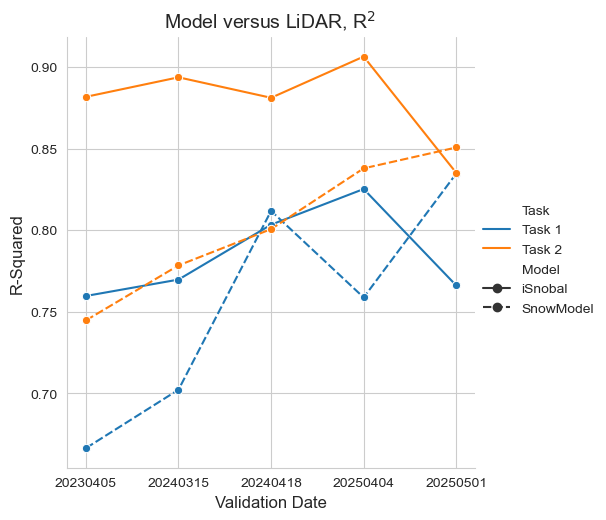

In [8]:

g = sns.relplot(
    data=df_filtered,
    x='Date',
    y='r-squared',
    hue='Task',
    palette=sns.color_palette(),
    style='Model',
    kind='line',
    markers = 'o',
    legend='full'
)

g.set_axis_labels("Validation Date", "R-Squared", fontsize=12)
plt.title("Model versus LiDAR, R$^2$ ", size=14) # Add title
plt.show()

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_31288\496652026.py:1: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  g = sns.relplot(
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_31288\496652026.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


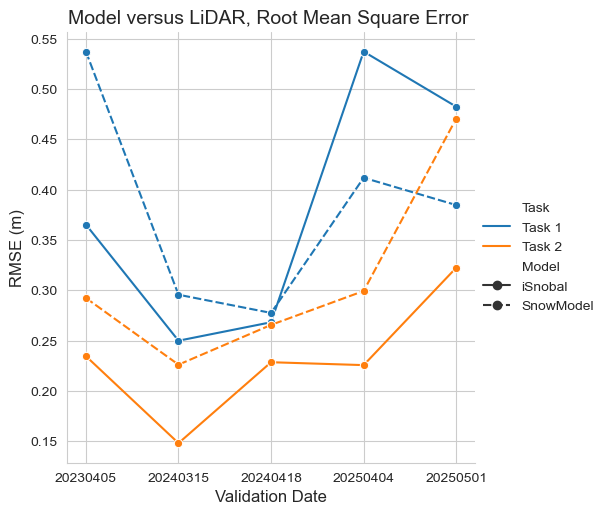

In [9]:

g = sns.relplot(
    data=df_filtered,
    x='Date',
    y='RMSE',
    hue='Task',
    palette=sns.color_palette(),
    style='Model',
    kind='line',
    markers = 'o',
    legend='full'
)

g.set_axis_labels("Validation Date", "RMSE (m)", fontsize=12)
plt.title("Model versus LiDAR, Root Mean Square Error ", size=14) # Add title
plt.show()

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4), sharey=True)

models = ['HMS-Energy-Balance', 'HMS-Temperature-Index', 'iSnobal', 'SnowModel']

for i, model in enumerate(models):
    sns.lineplot(
        data=df[df['model'] == model],
        x='date',
        y='rmse',
        hue='task',
        marker='o',
        ax=axs[i],
          
    )
    axs[i].get_legend().remove()
    axs[i].set_title(model)
    axs[i].set_xlabel("")
    #axs[i].tick_params(labelrotation=45)
    axs[0].set_ylabel("RMSE (m)")
    
    handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3)

plt.tight_layout()
plt.show()

In [ ]:
# Assume 'lidar' is defined somewhere in your script as before

def create_regression_plot(YYYYMMDD, plot_title):
    """
    Generates and displays a 4-panel regression plot for snow depth models.

    Args:
        resample_data (dict): A dictionary where keys are model names and values 
                              are paths to the model's raster data.
        plot_date (str): The date string to be used as the main title for the figure.
    """
    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample = task1[date]['resample']

    # --- Loop through each model to create a subplot ---
    for i, (name, model_data_path) in enumerate(resample.items()):
        raster = rxr.open_rasterio(model_data_path, masked=True).squeeze()
        
        # 1. Flatten and clean data
        x = lidar.values.flatten()
        y = raster.values.flatten()
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]

        ax = axs[i]
        
        # 2. Create the regression plot
        sns.regplot(x=x_clean, y=y_clean, ax=ax,
                    scatter_kws={'alpha': 0.8, 's': 10},
                    line_kws={'color': 'red'})
                    
        # 3. Calculate statistics
        slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
        r_squared = r_value**2
        
        # 4. Add titles and labels
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # 5. Add statistics text box
        stats_text = f'$R^2 = {r_squared:.3f}$\n$y = {slope:.2f}x + {intercept:.2f}$'
        ax.text(0.05, 0.95, stats_text, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



In [ ]:
# from rasterio.plot import show
   
date = '20230405'
lidar = task1[date]['lidar']
lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
lidar = lidar.where(lidar < 5)
resample_task1 = task1[date]['resample']
resample_task2 = task2[date]['resample']
keys = list(resample_task1.keys())
    
model_name = 'iSnobal'
y1 = rxr.open_rasterio(resample_task1[model_name], masked=True).squeeze()
y2 = rxr.open_rasterio(resample_task2[model_name], masked=True).squeeze()
        
x = lidar.values.flatten()
y1_flat = y1.values.flatten()
y2_flat = y2.values.flatten()

nan_mask = ~np.isnan(x) & ~np.isnan(y1_flat) & ~np.isnan(y2_flat)

x_clean = x[nan_mask]
y1_clean = y1_flat[nan_mask]
y2_clean = y2_flat[nan_mask]

        # slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x, y1_flat)
print(linregress(x_clean, y1_clean))
#         # r_squared1 = r_value1**2
#         # print(slope1, intercept1, r_value1, p_value1, std_err1)
#         
#         # slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x, y2_flat)
print(linregress(x_clean, y2_clean))
        # r_squared2 = r_value2**2
        # print(slope2, intercept2, r_value2, p_value2, std_err2)

In [ ]:
def regression_plot_compare(YYYYMMDD, plot_title):

    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample_task1 = task1[date]['resample']
    resample_task2 = task2[date]['resample']
    keys = list(resample_task1.keys())
    
    for idx in range(len(resample_task1)):
        ax = axs[idx]
        model_name = keys[idx]
        y1 = rxr.open_rasterio(resample_task1[model_name], masked=True).squeeze()
        y2 = rxr.open_rasterio(resample_task2[model_name], masked=True).squeeze()
        
        x = lidar.values.flatten()
        y1_flat = y1.values.flatten()
        y2_flat = y2.values.flatten()
        
        nan_mask = ~np.isnan(x) & ~np.isnan(y1_flat) & ~np.isnan(y2_flat)

        x_clean = x[nan_mask]
        y1_clean = y1_flat[nan_mask]
        y2_clean = y2_flat[nan_mask]

        sns.regplot(x=x, y=y1_flat, fit_reg=False, ax=axs[idx]) #scatter_kws={'alpha': 0.8, 's': 10})
        sns.regplot(x=x, y=y2_flat, fit_reg=False, ax=axs[idx]) #scatter_kws={'alpha': 0.8, 's': 10})
        start = [0,0]
        end = [4,4]
        ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')

        # # 3. Calculate statistics
        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_clean, y1_clean)
        r_squared1 = r_value1**2
        
        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x_clean, y2_clean)
        r_squared2 = r_value2**2
        
        # 4. Add titles and labels
        ax.set_title(model_name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # # 5. Add statistics text box
        stats_text1 = f'$R^2 = {r_squared1:.3f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
        ax.text(0.05, 0.95, stats_text1, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
        
        stats_text2 = f'$R^2 = {r_squared2:.3f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
        ax.text(0.35, 0.95, stats_text2, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



In [ ]:
regression_plot_compare('20230405', "April 5, 2023")
# regression_plot_compare('20240315', "March 15, 2024")
# regression_plot_compare('20240418', "April 18, 2024")
# regression_plot_compare('20250404', "April 4, 2025")
# regression_plot_compare('20250501', "May 1, 2025")

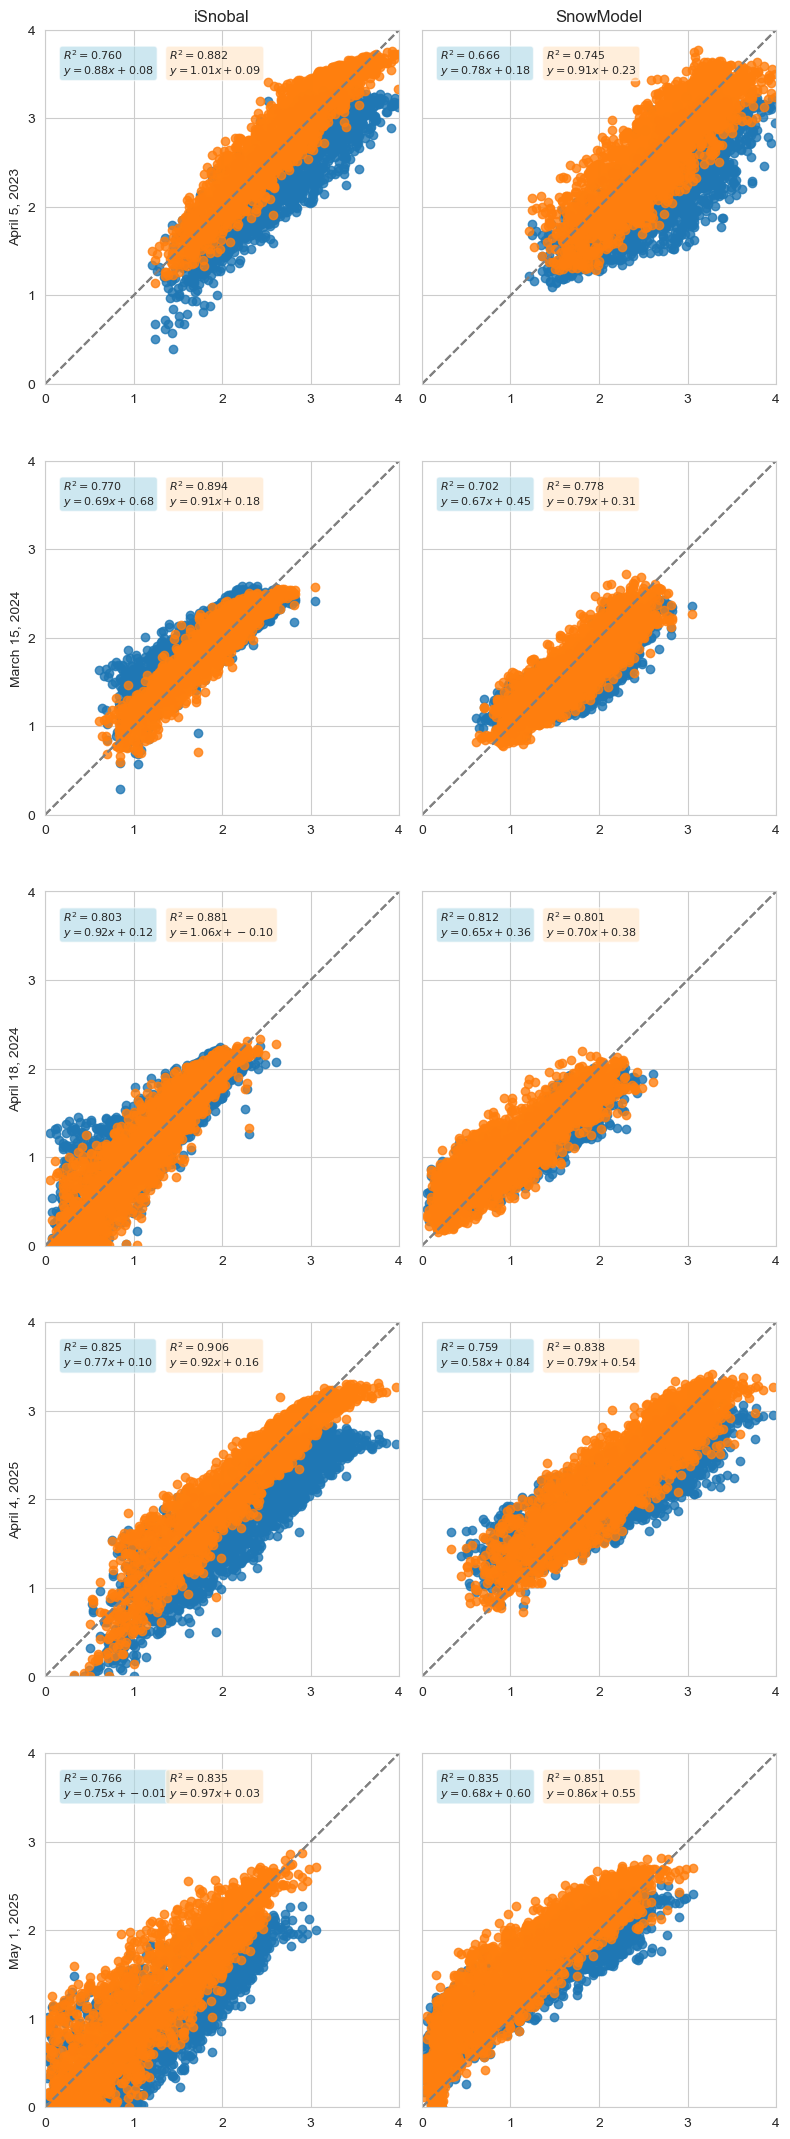

In [166]:
dates = ['April 5, 2023', 'March 15, 2024', 'April 18, 2024', 'April 4, 2025', 'May 1, 2025']

sns.set_style('whitegrid')

fig, axs = plt.subplots(
    nrows=5, ncols=2,
    figsize=(8,22),
    sharey=True
)
fig.suptitle("", fontsize=18, fontweight='bold')
cols = ['iSnobal', 'SnowModel']
for ax, col in zip(axs[0], cols):
    ax.set_title(col)

resample_task1 = []
resample_task2 = []
lidar_list = []

for key in task1.keys():
    date = key
    lidar = task1[date]['lidar']
    lidar_list.append(lidar)
    resample_task1.append({
        "iSnobal" : task1[date]['resample']['iSnobal'], 
        "SnowModel" : task1[date]['resample']['SnowModel']})
    
    resample_task2.append({
        "iSnobal" : task2[date]['resample']['iSnobal'], 
        "SnowModel" : task2[date]['resample']['SnowModel']})
    

for idx in range(len(resample_task1)):

    # Load LiDAR
    lidar = rxr.open_rasterio(lidar_list[idx], masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    x = lidar.values.flatten()

    ax = axs[idx,0]   
    y1 = rxr.open_rasterio(resample_task1[idx]['iSnobal'], masked=True).squeeze()
    y2 = rxr.open_rasterio(resample_task2[idx]['iSnobal'], masked=True).squeeze()
    y1 = y1.values.flatten()
    y2 = y2.values.flatten()

    mask = ~np.isnan(x) & ~np.isnan(y1) & ~np.isnan(y2)

    sns.regplot(x=x[mask], y=y1[mask], fit_reg=False, ax=ax)
    sns.regplot(x=x[mask], y=y2[mask], fit_reg=False, ax=ax)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_aspect('equal', adjustable='box')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel(dates[idx])
    start = [0,0]
    end = [4,4]
    ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')
    # # 3. Calculate statistics
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x[mask], y1[mask])
    r_squared1 = r_value1**2
    
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x[mask], y2[mask])
    r_squared2 = r_value2**2

    # # 5. Add statistics text box
    stats_text1 = f'$R^2 = {r_squared1:.3f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
    ax.text(0.05, 0.95, stats_text1, 
            transform=ax.transAxes, 
            fontsize=8, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
    
    stats_text2 = f'$R^2 = {r_squared2:.3f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
    ax.text(0.35, 0.95, stats_text2, 
            transform=ax.transAxes, 
            fontsize=8, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

#######################################################
    # SnowModel (col 1)
    ax = axs[idx,1]  

    y1 = rxr.open_rasterio(resample_task1[idx]['SnowModel'], masked=True).squeeze()
    y2 = rxr.open_rasterio(resample_task2[idx]['SnowModel'], masked=True).squeeze()

    y1 = y1.values.flatten()
    y2 = y2.values.flatten()

    mask = ~np.isnan(x) & ~np.isnan(y1) & ~np.isnan(y2)

    sns.regplot(x=x[mask], y=y1[mask], fit_reg=False, ax=ax)
    sns.regplot(x=x[mask], y=y2[mask], fit_reg=False, ax=ax)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_aspect('equal', adjustable='box')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    start = [0,0]
    end = [4,4]
    ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')
    # # 3. Calculate statistics
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x[mask], y1[mask])
    r_squared1 = r_value1**2
    
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x[mask], y2[mask])
    r_squared2 = r_value2**2

    # # 5. Add statistics text box
    stats_text1 = f'$R^2 = {r_squared1:.3f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
    ax.text(0.05, 0.95, stats_text1, 
            transform=ax.transAxes, 
            fontsize=8, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
    
    stats_text2 = f'$R^2 = {r_squared2:.3f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
    ax.text(0.35, 0.95, stats_text2, 
            transform=ax.transAxes, 
            fontsize=8, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

plt.tight_layout()
plt.show()

In [ ]:
diff_list = []
for date in task1.keys():
    diff_task1 = task1[date]['diff']
    diff_task2 = task2[date]['diff']
    diff_list.append(list(diff_task1.values()) + list(diff_task2.values()))

#print(diff_list)
for date in diff_list:
    for filepath in date:
        path = Path(filepath)
        if path.exists():
            print(path)
        else:
            print('File not found--------------------------------------------\n{filepath}\n')

In [ ]:

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(8.5, 8))#, sharex='col')
fig.suptitle(f'Task 1 & 2 Comparison, {date}', fontsize=16)
vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

for i, (model_name, task1_path) in enumerate(diff_task1.items()):
    task2_path = diff_task2[model_name]

    # --- Process and Plot Task 1 ---
    with rasterio.open(task1_path) as src:
        task1_data = src.read(1)
        nodata_val = src.nodata
        bounds = src.bounds
    with rasterio.open(task2_path) as src:
        task2_data = src.read(1)
        nodata_val = src.nodata
        data = task2_data - task1_data

    # Plot the raster image in the first column
    ax_img1 = axs[i, 0]
    im = ax_img1.imshow(data, cmap=colormap,norm=normalize, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax_img1.grid(False)
    ax_img1.set_ylabel(model_name, fontsize=9, va="bottom", labelpad=20, fontweight='bold')

    if i  != 3:
        ax_img1.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=True, right=False, labelbottom=False, labelleft=True, length=0)
    else:
        ax_img1.tick_params(axis='x', labelrotation=45)
    
    # Plot the histogram in the second column
    ax_hist1 = axs[i, 1]
    ax_hist1.grid(False)
    task1_flat = task1_data[task1_data != nodata_val].flatten() if nodata_val is not None else task1_data.flatten()
    ax_hist1.hist(task1_flat, bins=50,range=(-2,2))
    ax_hist1.axvline(0, color='red', linestyle='-', linewidth=1)
    if i  != 3:
        ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=False, right=False, labelbottom=False, labelleft=False)
    else:
        ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=False, right=False, labelbottom=True, labelleft=False)

    
    # Plot the histogram in the fourth column
    ax_hist2 = axs[i, 2]
    ax_hist2.grid(False)
    task2_flat = task2_data[task2_data != nodata_val].flatten() if nodata_val is not None else task2_data.flatten()
    ax_hist2.hist(task2_flat, bins=50, range=(-2,2))
    ax_hist2.axvline(0, color='red', linestyle='-', linewidth=1)
    
    if i  != 3:
        ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=False, right=False, labelbottom=False, labelleft=False)
    else:
        ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=False, right=False, labelbottom=True, labelleft=False)

ax_img1 = axs[0,0]
ax_hist1 = axs[0, 1]
ax_hist2 = axs[0, 2]
ax_img1.set_title('Task 2 -Task 1', fontsize=9, fontweight='bold')
ax_hist1.set_title('Lidar -Task 1', fontsize=9, fontweight='bold')
ax_hist2.set_title('Lidar - Task 2', fontsize=9, fontweight='bold')

plt.subplots_adjust(left=0.1, right=0.85, bottom=0.1, top=0.9, wspace=0.1, hspace=0.1)
cbar_ax = fig.add_axes([0.9, 0.25, 0.02, 0.6]) # [left, bottom, width, height]

# Add the colorbar to the *newly created* axes (cbar_ax)
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=10)
# Adjust layout to prevent titles and labels from overlapping
# Display the plot
plt.show()


In [ ]:

for i, keys in enumerate(task1.keys()):
    print(keys)
    print(i)

NameError: name 'key' is not defined

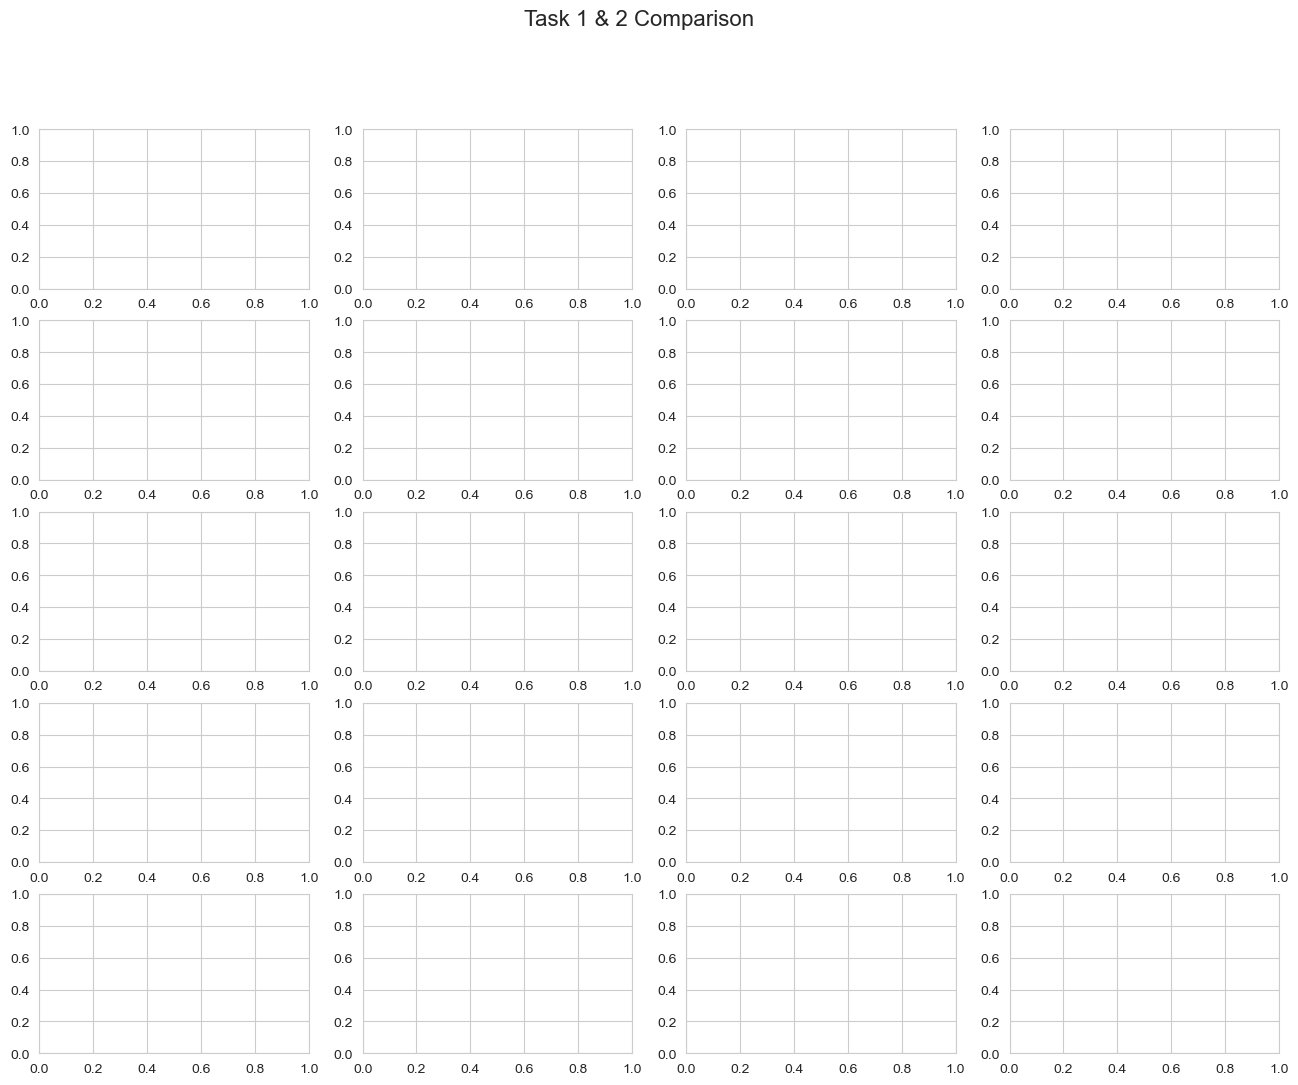

In [4]:

fig, axs = plt.subplots(nrows=5, ncols=4, figsize = (16,12))#, sharex='col')
fig.suptitle(f'Task 1 & 2 Comparison', fontsize=16)
vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r


for i, (keys) in enumerate(task1.keys()):
    m1 = task1[key]['resample']['iSnobal']
    m2 = task2[key]['resample']['iSnobal']

    # --- Process and Plot Task 1 ---
    with rasterio.open(m1) as src:
        task1_data = src.read(1)
        nodata_val = src.nodata
        bounds = src.bounds
    with rasterio.open(m2) as src:
        task2_data = src.read(1)
        nodata_val = src.nodata
        data = task2_data - task1_data

    # Plot the raster image in the first column
    ax_img1 = axs[i, 0]
    im = ax_img1.imshow(data, cmap=colormap,norm=normalize, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax_img1.grid(False)
    #ax_img1.set_ylabel(model_name, fontsize=9, va="bottom", labelpad=20, fontweight='bold')

    if i  != 3:
        ax_img1.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=True, right=False, labelbottom=False, labelleft=True, length=0)
    else:
        ax_img1.tick_params(axis='x', labelrotation=45)
    
    # # Plot the histogram in the second column
    # ax_hist1 = axs[i, 1]
    # ax_hist1.grid(False)
    # task1_flat = task1_data[task1_data != nodata_val].flatten() if nodata_val is not None else task1_data.flatten()
    # ax_hist1.hist(task1_flat, bins=50,range=(-2,2))
    # ax_hist1.axvline(0, color='red', linestyle='-', linewidth=1)
    # if i  != 3:
    #     ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
    #                       left=False, right=False, labelbottom=False, labelleft=False)
    # else:
    #     ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
    #                       left=False, right=False, labelbottom=True, labelleft=False)
    # 
    # 
    ##################################################################################
    m1 = task1[key]['resample']['SnowModel']
    m2 = task2[key]['resample']['SnowModel']

    # --- Process and Plot Task 1 ---
    with rasterio.open(m1) as src:
        task1_data = src.read(1)
        nodata_val = src.nodata
        bounds = src.bounds
    with rasterio.open(m2) as src:
        task2_data = src.read(1)
        nodata_val = src.nodata
        data = task2_data - task1_data

    # Plot the raster image in the first column
    ax_img1 = axs[i, 2]
    im = ax_img1.imshow(data, cmap=colormap,norm=normalize, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax_img1.grid(False)
    #ax_img1.set_ylabel(model_name, fontsize=9, va="bottom", labelpad=20, fontweight='bold')
    
    
    # # Plot the histogram in the fourth column
    # ax_hist2 = axs[i, 3]
    # ax_hist2.grid(False)
    # task2_flat = task2_data[task2_data != nodata_val].flatten() if nodata_val is not None else task2_data.flatten()
    # ax_hist2.hist(task2_flat, bins=50, range=(-2,2))
    # ax_hist2.axvline(0, color='red', linestyle='-', linewidth=1)
    # 
    # if i  != 3:
    #     ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
    #                       left=False, right=False, labelbottom=False, labelleft=False)
    # else:
    #     ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
    #                       left=False, right=False, labelbottom=True, labelleft=False)

# ax_img1 = axs[0,0]
# ax_hist1 = axs[0, 1]
# ax_hist2 = axs[0, 2]
# ax_img1.set_title('Task 2 -Task 1', fontsize=9, fontweight='bold')
# ax_hist1.set_title('Lidar -Task 1', fontsize=9, fontweight='bold')
# ax_hist2.set_title('Lidar - Task 2', fontsize=9, fontweight='bold')

plt.subplots_adjust(left=0.1, right=0.85, bottom=0.1, top=0.9, wspace=0.1, hspace=0.1)
cbar_ax = fig.add_axes([0.9, 0.25, 0.02, 0.6]) # [left, bottom, width, height]

# Add the colorbar to the *newly created* axes (cbar_ax)
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=10)
# Adjust layout to prevent titles and labels from overlapping
# Display the plot
plt.show()


In [ ]:
date = '20230405'

basin_task1 = task1[date]['basin_clip']
basin_task2 = task2[date]['basin_clip']
HMSEB = basin_task1['HMS-EB']
HMSTI = basin_task1['HMS-TI']
iSnobal = basin_task1['iSnobal']
SnowModel = basin_task1['SnowModel']

raster_list = {'HMS-EB': HMSEB, 'SnowModel': SnowModel, 'iSnobal': iSnobal}

In [ ]:
vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 4), sharex=True, sharey=True)#, sharex='col')

with rasterio.open(HMSTI) as ref:
    TI = ref.read(1, masked=True)
    profile = ref.profile
    extent = [ref.bounds.left, ref.bounds.right, ref.bounds.bottom, ref.bounds.top]
    
    for i, (model, data) in enumerate(raster_list.items()):
        with rasterio.open(data) as src:
            reprojected_data = np.empty_like(TI)
            
            reproject(
                source=src.read(1),  # <-- CORRECTED: Use the source data
                destination=reprojected_data,
                src_transform=src.transform,
                src_crs='EPSG:32611',
                dst_transform=profile['transform'],
                dst_crs='EPSG:32611',
                resampling=Resampling.bilinear
            )
            reprojected_data = np.ma.masked_equal(reprojected_data, ref.nodata)
            diff = TI - reprojected_data 
        
            im = axs[i].imshow(diff, cmap=colormap, norm = normalize, extent=extent)
            
            axs[i].set_title(model)
            axs[i].grid(False)
            
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space
# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.9, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=10)

fig.suptitle("", fontsize=16,  y=0.95)

fig.subplots_adjust(
    wspace=0.05,
    hspace=0.06,
    right=0.88
    #top=0.90
)

plt.show() 


In [ ]:
date = '20230405'

basin_task1 = task1[date]['basin_clip']
basin_task2 = task2[date]['basin_clip']
HMSEB = basin_task1['HMS-EB']
HMSTI = basin_task1['HMS-TI']
iSnobal = basin_task1['iSnobal']
SnowModel = basin_task1['SnowModel']

raster_list = {'HMS-EB': HMSEB,'HMS-TI':HMSTI, 'SnowModel': SnowModel, 'iSnobal': iSnobal}

In [ ]:
HMSTI

In [ ]:
vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(12, 12),
                        sharex=True, sharey=True)

for i, (row_model, row_path) in enumerate(raster_list.items()):
    
    with rasterio.open(row_path) as ref:
        row_data = ref.read(1, masked=True)
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_nodata = ref.nodata
        extent = [ref.bounds.left, ref.bounds.right,
                  ref.bounds.bottom, ref.bounds.top]

        for j, (col_model, col_path) in enumerate(raster_list.items()):
            
            with rasterio.open(col_path) as src:
                src_data = src.read(1)
                
                # Allocate destination array
                dst = np.empty_like(row_data, dtype=np.float32)

                reproject(
                    source=src_data,
                    destination=dst,
                    src_transform=src.transform,
                    src_crs='EPSG:32611',
                    src_nodata=-9999,
                    dst_transform=ref_transform,
                    dst_crs='EPSG:32611',
                    dst_nodata=-9999,
                    resampling=Resampling.bilinear
                )

                # Mask nodata
                dst = np.ma.masked_equal(dst, -9999)
                
                # Column minus row
                diff = dst - row_data
                
                print(diff.min(), diff.max())

                ax = axs[i, j]
                im = ax.imshow(diff,
                               cmap=colormap,
                               norm=normalize,
                               extent=extent)
                ax.set_title(f"{col_model} - {row_model}")
                ax.grid(False)
                
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space
# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.9, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=16)

plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/basin_compare.png", dpi=600)


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(8, 10), sharex=True, sharey=True)
axes = axes.flatten()  # flatten to 1D array for easy looping

for i, (model, raster) in enumerate(raster_list.items()):

    with rasterio.open(raster) as src:
        data = src.read(1, masked=True)  # read first band, mask NoData
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    im = axes[i].imshow(data, cmap="viridis",
                        extent=extent,
                        vmin=0,vmax=4.0 )
    axes[i].set_title(model)
    axes[i].grid(False)
    basin_shp.plot(ax=axes[i], facecolor='none', edgecolor='blue', linewidth=1.5)

    lidar_shp.plot(ax=axes[i], facecolor='none', edgecolor='black', linewidth=1.5)


# Add colorbar

#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, extend="max", label="Snow Depth")

# --- 5. Add a single, shared colorbar ---
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space

# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth (m)', fontsize=14)

fig.suptitle(f"Mores Creek Basin Snow Depth, April 5, 2023", fontsize=16,  y=0.95)

fig.subplots_adjust(
    wspace=0.05,
    hspace=0.06,
    right=0.88
    #top=0.90
)

plt.show()

In [ ]:
def count_unique_raster_values_rasterstats(raster_path, polygon_path):
    # Load the polygon shapefile
    gdf = gpd.read_file(polygon_path)
    
    with rasterio.open(raster_path) as src:
        # Read the first band into a numpy array
        affine_transform = src.transform
        data = src.read(1, masked=True)
        with np.errstate(invalid='ignore'):
                 rounded_data = np.round(data, 2)        

        stats = zonal_stats(polygon_path, 
                            rounded_data, 
                            categorical=True, 
                            affine=affine_transform,
                            stats=['unique']) # You can use other stats like 'mean', 'count'
    
        # The 'unique' statistic returns a dictionary of counts.
        # For the first polygon:
        if stats:
            unique_counts = stats[0]
            print(f"Total number of unique raster values within the first polygon: {len(unique_counts)}")
            #print("Counts of each unique value:", unique_counts)
            #return unique_counts
        else:
            print("No data found within the polygon extent.")
            return None

# Example usage (replace with your file paths)
# raster_file = "your_raster.tif"
# polygon_file = "your_polygon.shp"
# count_unique_raster_values_rasterstats(raster_file, polygon_file)


In [ ]:
count_unique_raster_values_rasterstats(EM, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/MCS_outline/basin_outline.shp")
count_unique_raster_values_rasterstats(TI, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/MCS_outline/basin_outline.shp")
count_unique_raster_values_rasterstats(iSnobal, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/MCS_outline/basin_outline.shp")
count_unique_raster_values_rasterstats(SnowModel, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/MCS_outline/basin_outline.shp")

count_unique_raster_values_rasterstats(EM, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/MCS_outline/MCS_outline.shp")
count_unique_raster_values_rasterstats(TI, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/MCS_outline/MCS_outline.shp")
count_unique_raster_values_rasterstats(iSnobal, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/MCS_outline/MCS_outline.shp")
count_unique_raster_values_rasterstats(SnowModel, "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/MCS_outline/MCS_outline.shp")



## I need to resample LIDAR data to match HMS, rather than HMS to match LiDAR. I then need to repeat my regressions.

In [ ]:
for keys in task1.keys():
    print(keys)

In [ ]:
def HMS_dates(dir):
    dictionary = {"20230405": glob.glob(os.path.join(dir,'*2023_04_05*')),
                       "20240315": glob.glob(os.path.join(dir, '*2024_03_15*')),
                       "20240418": glob.glob(os.path.join(dir, '*2024_04_18*')) + glob.glob(os.path.join(dir, '*2024_04_15*')),
                       "20250404": glob.glob(os.path.join(dir, '*2025_04_04*')),
                       "20250501": glob.glob(os.path.join(dir, '*2025_05_01*')),}

    return dictionary

In [ ]:
EB_t1 = HMS_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task1/2026.01.16_HMS_results/EB/snow_depth")
TI_t1 = HMS_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task1/2026.01.16_HMS_results/TI/snowdepth")

EB_t2 = HMS_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task2/HMS_Task2/WY2023-2025_EB_HRRR_2000m")
TI_t2 = HMS_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task2/HMS_Task2/WY2023-2025_TI_HRRR_2000m")

In [ ]:
for date in task1.keys():
    lidar = task1[date]['lidar']
    print(lidar)


In [ ]:
model, raster_list = list(TI_t1.items())[0]
raster_path = raster_list[0] 
print(raster_path)

out_dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task1/lidar_HMS"
ref = rxr.open_rasterio(raster_path)

for date in task1.keys():
    lidar = task1[date]['lidar']
    source = rxr.open_rasterio(lidar)
    reprojected_raster = source.rio.reproject_match(ref)
    reprojected_raster.rio.to_raster(os.path.join(out_dir, f"{date}_reprojected.tif"), driver='GTiff')   

In [ ]:
lidar_dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task1/lidar_HMS"

lidar_dict = {"20230405": glob.glob(os.path.join(lidar_dir,'*20230405*')),
                       "20240315": glob.glob(os.path.join(lidar_dir, '*20240315*')),
                       "20240418": glob.glob(os.path.join(lidar_dir, '*20240418*')) + glob.glob(os.path.join(lidar_dir, '*2024_04_15*')),
                       "20250404": glob.glob(os.path.join(lidar_dir, '*20250404*')),
                       "20250501": glob.glob(os.path.join(lidar_dir, '*20250501*')),}

lidar_dict

In [ ]:
for keys in lidar_dict.keys():
    print(keys)
    
for keys in EB_t1.keys():
    print(keys)   
    
lidar_dict['20230405']

In [ ]:
sns.set_style('whitegrid')
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(22, 5), sharey=True)
fig.suptitle("HMS Temperature Index", fontsize=18, fontweight='bold')
date_keys = list(lidar_dict.keys())

# --- select data

for idx, date in enumerate(date_keys):

    lidar_path = lidar_dict[date][0]
    t1_path = TI_t1[date][0]
    t2_path = TI_t2[date][0]
    
    lidar = rxr.open_rasterio(lidar_path, masked=True).squeeze()
    y1 = rxr.open_rasterio(t1_path, masked=True).squeeze()
    y2 = rxr.open_rasterio(t2_path, masked=True).squeeze()
    
    x_flat = lidar.values.flatten()
    y1_flat = y1.values.flatten()
    y2_flat = y2.values.flatten()
        
    y1_m = y1_flat * 0.0254 # Assuming original is inches
    y2_m = y2_flat * 0.0254
        
    nan_mask = ~np.isnan(x_flat) & ~np.isnan(y1_m) & ~np.isnan(y2_m)

    x_clean = x_flat[nan_mask]
    y1_clean = y1_m[nan_mask]
    y2_clean = y2_m[nan_mask]

    ax = axs[idx]    
    sns.regplot(x=x_clean, y=y1_clean, fit_reg=False, ax=ax) #scatter_kws={'alpha': 0.8, 's': 10})
    sns.regplot(x=x_clean, y=y2_clean, fit_reg=False, ax=ax) #scatter_kws={'alpha': 0.8, 's': 10})
    start = [0,0]
    end = [3,3]
    ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')

    # # 3. Calculate statistics
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_clean, y1_clean)
    r_squared1 = r_value1**2
    
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x_clean, y2_clean)
    r_squared2 = r_value2**2
    
    # 4. Add titles and labels
    ax.set_title(date, fontsize=14, fontweight='bold')
    ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

    # # 5. Add statistics text box
    stats_text1 = f'$R^2 = {r_squared1:.3f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
    ax.text(0.05, 0.95, stats_text1, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
    
    stats_text2 = f'$R^2 = {r_squared2:.3f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
    ax.text(0.35, 0.95, stats_text2, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

# --- Final Figure-Level Adjustments ---
axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
plt.tight_layout()

# Display the final plot
plt.show()



In [ ]:
sns.set_style('whitegrid')
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(22, 5), sharey=True)
fig.suptitle("HMS Energy Balance", fontsize=18, fontweight='bold')
date_keys = list(lidar_dict.keys())

# --- select data

for idx, date in enumerate(date_keys):

    lidar_path = lidar_dict[date][0]
    t1_path = EB_t1[date][0]
    t2_path = EB_t2[date][0]
    
    lidar = rxr.open_rasterio(lidar_path, masked=True).squeeze()
    y1 = rxr.open_rasterio(t1_path, masked=True).squeeze()
    y2 = rxr.open_rasterio(t2_path, masked=True).squeeze()
    
    x_flat = lidar.values.flatten()
    y1_flat = y1.values.flatten()
    y2_flat = y2.values.flatten()
        
    y1_m = y1_flat * 0.0254 # Assuming original is inches
    y2_m = y2_flat * 0.0254
        
    nan_mask = ~np.isnan(x_flat) & ~np.isnan(y1_m) & ~np.isnan(y2_m)

    x_clean = x_flat[nan_mask]
    y1_clean = y1_m[nan_mask]
    y2_clean = y2_m[nan_mask]

    ax = axs[idx]    
    sns.regplot(x=x_clean, y=y1_clean, fit_reg=False, ax=ax) #scatter_kws={'alpha': 0.8, 's': 10})
    sns.regplot(x=x_clean, y=y2_clean, fit_reg=False, ax=ax) #scatter_kws={'alpha': 0.8, 's': 10})
    start = [0,0]
    end = [3,3]
    ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')

    # # 3. Calculate statistics
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_clean, y1_clean)
    r_squared1 = r_value1**2
    
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x_clean, y2_clean)
    r_squared2 = r_value2**2
    
    # 4. Add titles and labels
    ax.set_title(date, fontsize=14, fontweight='bold')
    ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

    # # 5. Add statistics text box
    stats_text1 = f'$R^2 = {r_squared1:.3f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
    ax.text(0.05, 0.95, stats_text1, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
    
    stats_text2 = f'$R^2 = {r_squared2:.3f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
    ax.text(0.35, 0.95, stats_text2, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

# --- Final Figure-Level Adjustments ---
axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
plt.tight_layout()

# Display the final plot
plt.show()



## SNOTEL and Freeman comparison
### Extract depth at SNOTEL, Bogus Basin Snotel, and Freeman. Plot against snow depth data

In [3]:
snotel_point_MCS = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID
snotel_point_BB = SnotelPointData("978:ID:SNTL", "Bogus Basin") # define the snotel ID
MCS_SNOTEL = snotel_point_MCS.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_MCS.ALLOWED_VARIABLES.SNOWDEPTH])
    
BB_SNOTEL = snotel_point_BB.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_BB.ALLOWED_VARIABLES.SNOWDEPTH])  
MCS_SNOTEL["SNOWDEPTH (m)"] = MCS_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
BB_SNOTEL["SNOWDEPTH (m)"] = BB_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters


In [4]:
def x_y_snotel(snotel_station):
    """
    Convert Snotel from lon/lat to x/y
    """
    converter = Transformer.from_proj(Proj('EPSG:4326'), Proj('EPSG:32611'), always_xy=True)
    return converter.transform(snotel_station.metadata.x, snotel_station.metadata.y)

In [5]:
def get_raster_pixel_value(file, geo_x, geo_y):
    """
    Return value from raster at given geo coordinates
    """
    with gdal.Open(file) as dataset:
        gt = dataset.GetGeoTransform()

        pixel_coords = gdal.ApplyGeoTransform(
            gdal.InvGeoTransform(gt), geo_x, geo_y
        )
        pixel_x, pixel_y = int(pixel_coords[0]), int(pixel_coords[1])

        band = dataset.GetRasterBand(1)

        val_array = band.ReadAsArray(
            xoff=pixel_x, yoff=pixel_y, win_xsize=1, win_ysize=1
        )

        return val_array[0][0]

C:\Users\RDCRLSMC\AppData\Local\Temp\3\ipykernel_13508\2460096284.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left', fontsize = 14)


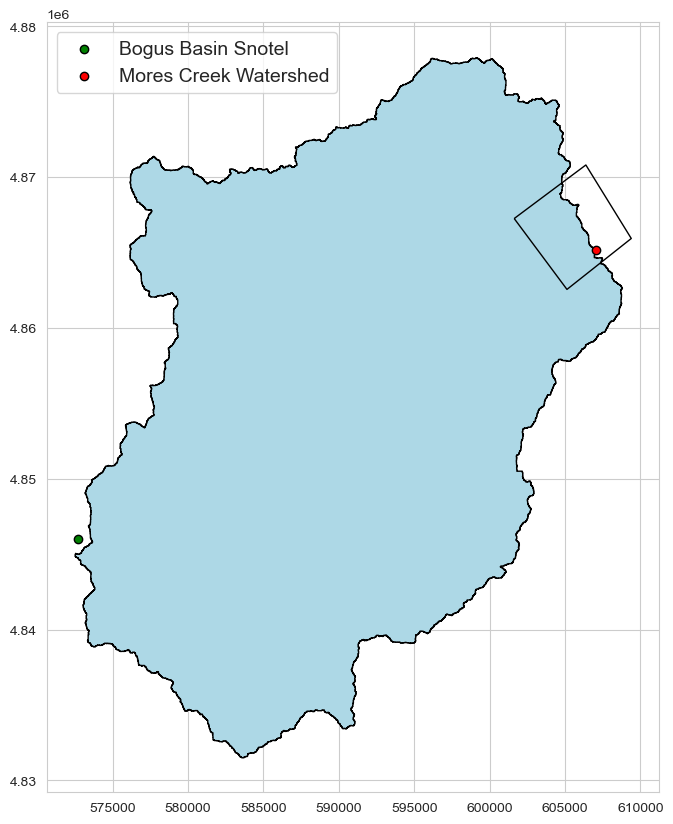

In [13]:
MCS = x_y_snotel(snotel_point_MCS)
BB = x_y_snotel(snotel_point_BB)
MCS_point = Point(MCS)
BB_point = Point(BB)

mcs_shp = gpd.read_file("C:/Users/RDCRLSMC/Desktop/GIS/MCS/MCS_shp/MCS_outline.shp")
basin_shp = gpd.read_file("C:/Users/RDCRLSMC/Desktop/GIS/basin/basin_outline.shp")
MCS_gdf = gpd.GeoDataFrame(index=[0], crs=basin_shp.crs, geometry=[MCS_point])
BB_gdf = gpd.GeoDataFrame(index=[0], crs=basin_shp.crs, geometry=[BB_point])


fig, ax = plt.subplots(figsize=(10, 10))
basin_shp.plot(ax=ax, color='lightblue', edgecolor='black', label='Mores Creek Watershed')
mcs_shp.plot(ax=ax, facecolor='none', edgecolor='black', label='LiDAR Domain')
BB_gdf.plot(ax=ax, color='green', edgecolor='black', label='Bogus Basin Snotel')
MCS_gdf.plot(ax=ax, color='red', edgecolor='black', label='Mores Creek Watershed')

ax.legend(loc='upper left', fontsize = 14)


In [18]:
snotel_df = []
    
for key, rasters in task1_raw_data.items():
    for rasters, filepath in rasters.items():
        MCS_depth = get_raster_pixel_value(filepath, MCS[0], MCS[1])
        BB_depth = get_raster_pixel_value(filepath, BB[0], BB[1])
        
        row = {
            "task" : "task 1",
            "date" : key,
            "model" : rasters,
            "MCS depth" : MCS_depth,
            "BB depth" : BB_depth

        }

        snotel_df.append(row)

for key, rasters in task2_raw_data.items():        
    for rasters, filepath in rasters.items():
        MCS_depth = get_raster_pixel_value(filepath, MCS[0], MCS[1])
        BB_depth = get_raster_pixel_value(filepath, BB[0], BB[1])
        
        row = {
            "task" : "task 2",
            "date" : key,
            "model" : rasters,
            "MCS depth" : MCS_depth,
            "BB depth" : BB_depth

        }

        snotel_df.append(row)

snotel_df = pd.DataFrame(snotel_df)


In [19]:
snotel_df["date"] = pd.to_datetime(snotel_df["date"], format='%Y%m%d')
snotel_df = snotel_df.set_index('date')

['datetime', 'site']


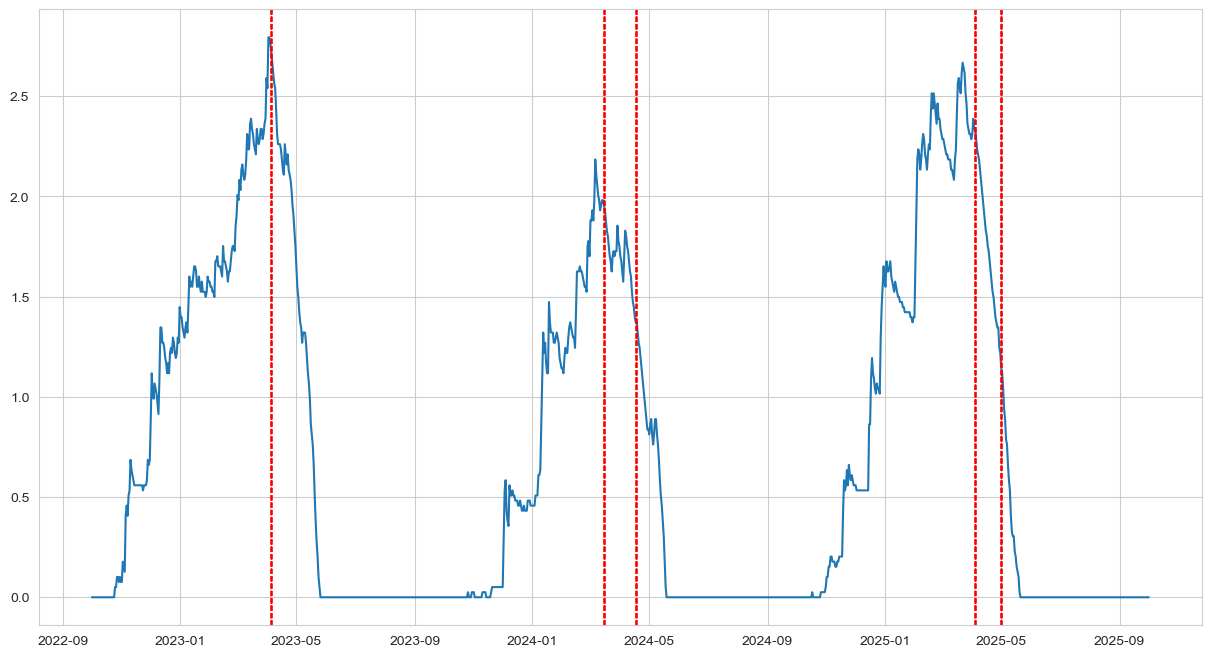

In [20]:
print(MCS_SNOTEL.index.names)
MCS_SNOTEL.columns
dates = MCS_SNOTEL.index.get_level_values('datetime')

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(dates, MCS_SNOTEL['SNOWDEPTH (m)'], label='SNOWDEPTH (m)')
for d in snotel_df.index:
    ax.axvline(
        x=d,
        color='red',
        linestyle='--',
        linewidth=1
    )

In [21]:
HMS_TI_t1 = snotel_df[
    (snotel_df['model'] == 'HMS_TI') &
    (snotel_df['task'] == 'task 1')
]

HMS_EB_t1 = snotel_df[
    (snotel_df['model'] == 'HMS_EB') &
    (snotel_df['task'] == 'task 1')
]

sm_t1 = snotel_df[
    (snotel_df['model'] == 'Snow Model') &
    (snotel_df['task'] == 'task 1')
]

isno_t1 = snotel_df[
    (snotel_df['model'] == 'iSnobal') &
    (snotel_df['task'] == 'task 1')
]



HMS_TI_t2 = snotel_df[
    (snotel_df['model'] == 'HMS_TI') &
    (snotel_df['task'] == 'task 2')
]

HMS_EB_t2 = snotel_df[
    (snotel_df['model'] == 'HMS_EB') &
    (snotel_df['task'] == 'task 2')
]

sm_t2 = snotel_df[
    (snotel_df['model'] == 'Snow Model') &
    (snotel_df['task'] == 'task 2')
]

isno_t2 = snotel_df[
    (snotel_df['model'] == 'iSnobal') &
    (snotel_df['task'] == 'task 2')
]



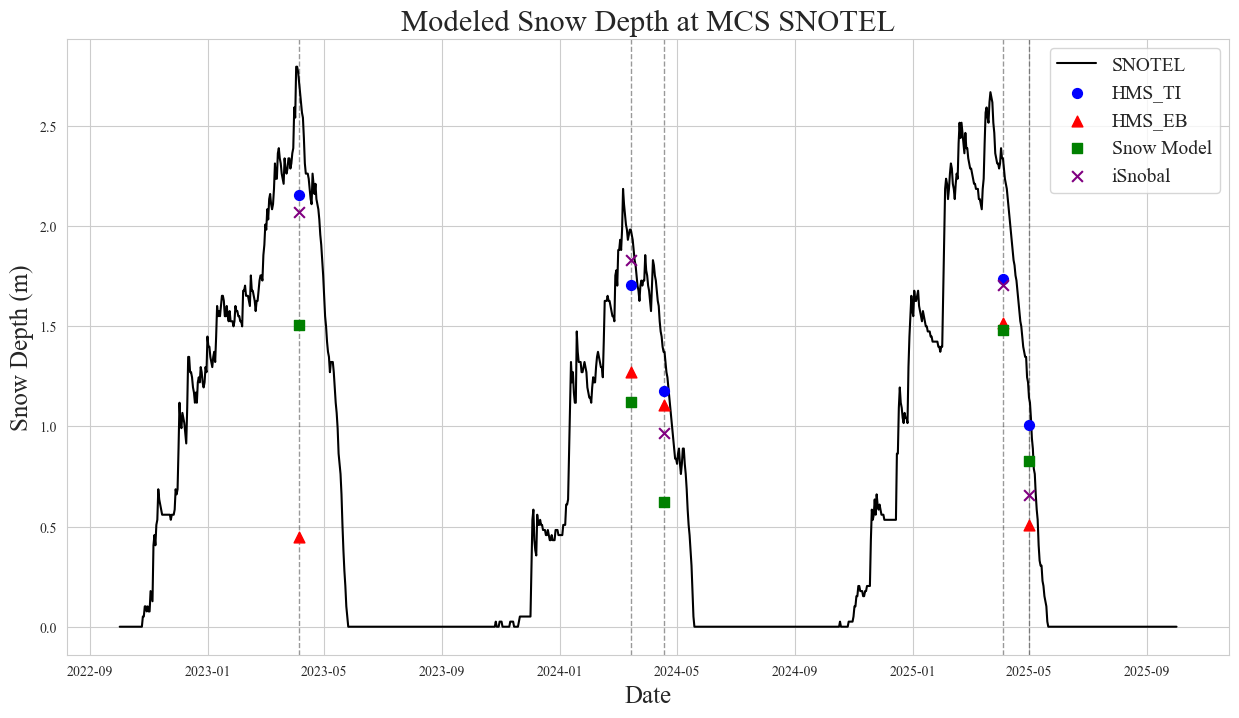

In [36]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(15, 8))
dates = MCS_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    MCS_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)

for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    HMS_TI_t1.index,
    HMS_TI_t1['MCS depth'],
    label='HMS_TI',
    color='blue',
    marker='o',
    s=50,
    zorder=3
)

# HMS EB (triangle up)
ax.scatter(
    HMS_EB_t1.index,
    HMS_EB_t1['MCS depth'],
    label='HMS_EB',
    color='red',
    marker='^',
    s=60,
    zorder=3
)

# Snow Model (square)
ax.scatter(
    sm_t1.index,
    sm_t1['MCS depth'],
    label='Snow Model',
    color='green',
    marker='s',
    s=50,
    zorder=3
)

# iSnobal (x marker)
ax.scatter(
    isno_t1.index,
    isno_t1['MCS depth'],
    label='iSnobal',
    color='purple',
    marker='x',
    s=60,
    zorder=3
)

ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.set_xlabel('Date', fontsize = 18)
ax.set_title("Modeled Snow Depth at MCS SNOTEL", fontsize=22)
ax.legend(fontsize = 14)

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/MCS_snotel_all.png')


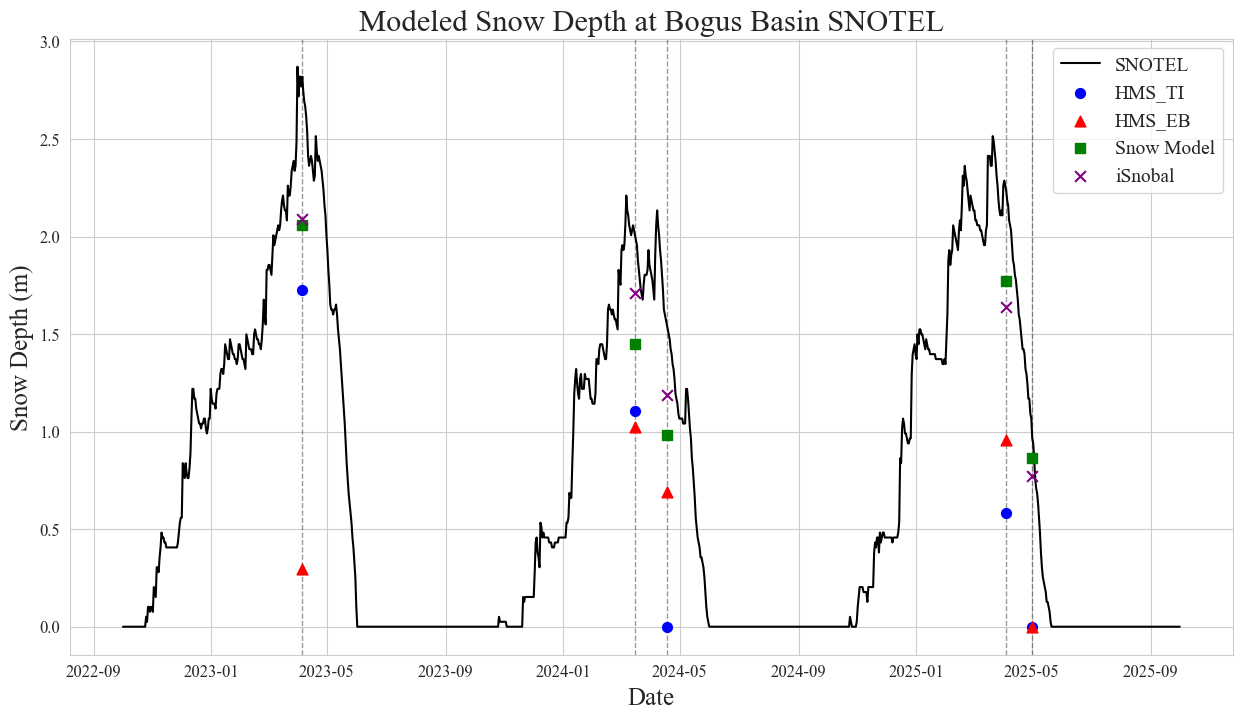

In [35]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = BB_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    BB_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    HMS_TI_t1.index,
    HMS_TI_t1['BB depth'],
    label='HMS_TI',
    color='blue',
    marker='o',
    s=50,
    zorder=3
)

# HMS EB (triangle up)
ax.scatter(
    HMS_EB_t1.index,
    HMS_EB_t1['BB depth'],
    label='HMS_EB',
    color='red',
    marker='^',
    s=60,
    zorder=3
)

# Snow Model (square)
ax.scatter(
    sm_t1.index,
    sm_t1['BB depth'],
    label='Snow Model',
    color='green',
    marker='s',
    s=50,
    zorder=3
)

# iSnobal (x marker)
ax.scatter(
    isno_t1.index,
    isno_t1['BB depth'],
    label='iSnobal',
    color='purple',
    marker='x',
    s=60,
    zorder=3
)

ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.set_xlabel('Date', fontsize = 18)
ax.tick_params(axis='both', labelsize=12)
ax.set_title("Modeled Snow Depth at Bogus Basin SNOTEL", fontsize=22)
ax.legend(fontsize = 14)

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/BB_snotel_all.png')

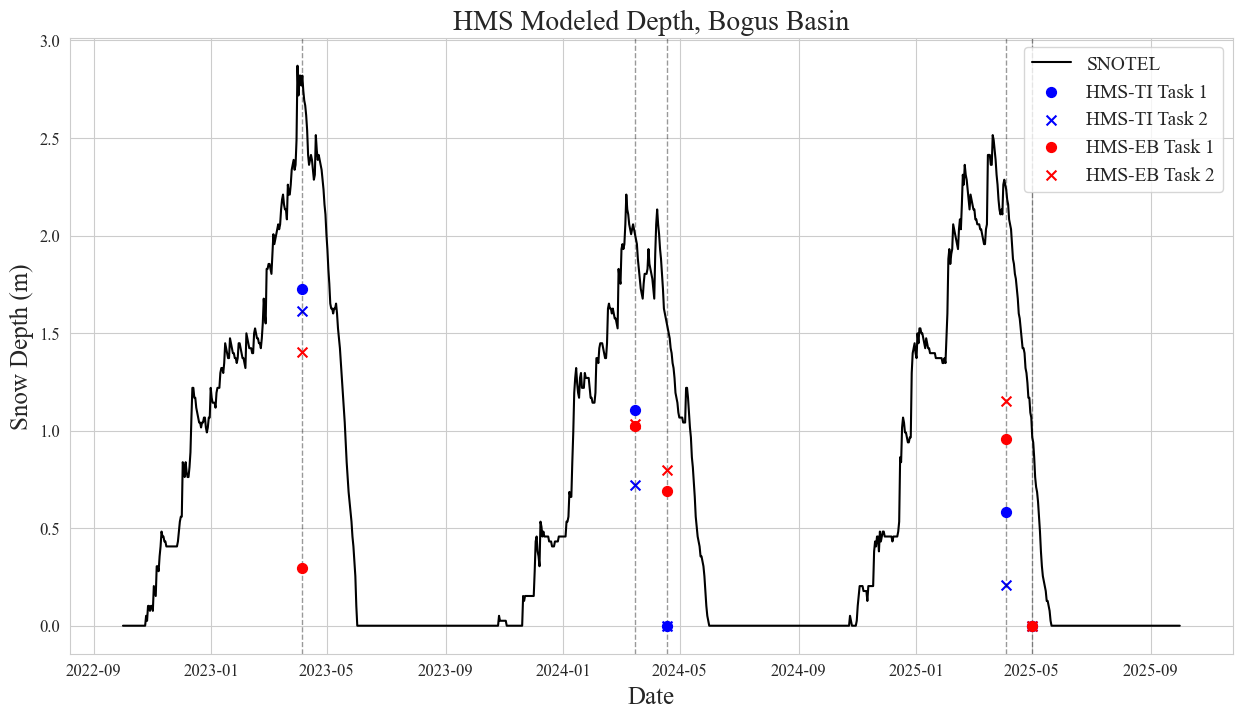

In [45]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = BB_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    BB_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    HMS_TI_t1.index,
    HMS_TI_t1['BB depth'],
    label='HMS-TI Task 1',
    color='blue',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    HMS_TI_t2.index,
    HMS_TI_t2['BB depth'],
    label='HMS-TI Task 2',
    color='blue',
    marker='x',
    s=50,
    zorder=1
)

ax.scatter(
    HMS_EB_t1.index,
    HMS_EB_t1['BB depth'],
    label='HMS-EB Task 1',
    color='red',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    HMS_EB_t2.index,
    HMS_EB_t2['BB depth'],
    label='HMS-EB Task 2',
    color='red',
    marker='x',
    s=50,
    zorder=3
)


ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.set_xlabel('Date', fontsize = 18)
ax.tick_params(axis='both', labelsize=12)
ax.set_title("HMS Modeled Depth, Bogus Basin", fontsize=20)
ax.legend(fontsize = 14, loc = 'upper right')

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/HMS_BBsnotel.png')

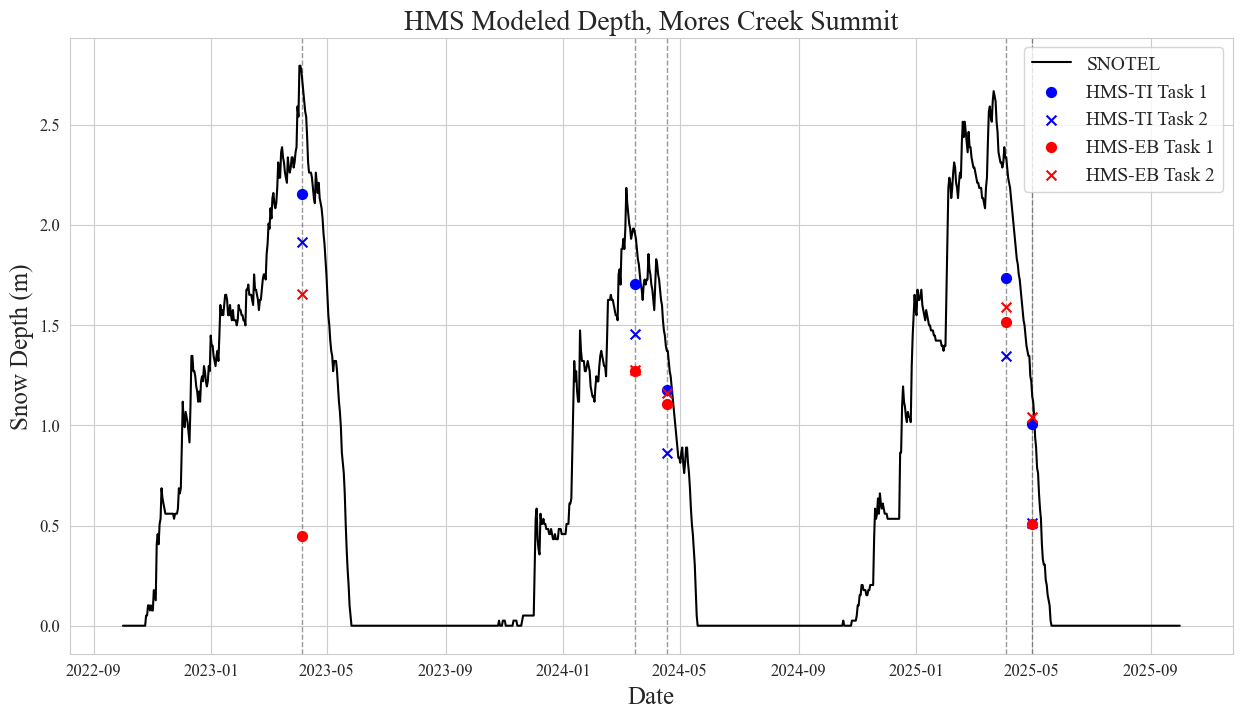

In [46]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = MCS_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    MCS_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    HMS_TI_t1.index,
    HMS_TI_t1['MCS depth'],
    label='HMS-TI Task 1',
    color='blue',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    HMS_TI_t2.index,
    HMS_TI_t2['MCS depth'],
    label='HMS-TI Task 2',
    color='blue',
    marker='x',
    s=50,
    zorder=1
)

ax.scatter(
    HMS_EB_t1.index,
    HMS_EB_t1['MCS depth'],
    label='HMS-EB Task 1',
    color='red',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    HMS_EB_t2.index,
    HMS_EB_t2['MCS depth'],
    label='HMS-EB Task 2',
    color='red',
    marker='x',
    s=50,
    zorder=3
)

ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.set_xlabel('Date', fontsize = 18)
ax.tick_params(axis='both', labelsize=12)
ax.set_title("HMS Modeled Depth, Mores Creek Summit", fontsize=20)
ax.legend(fontsize = 14, loc = 'upper right')

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/HMS_MCS_snotel.png')

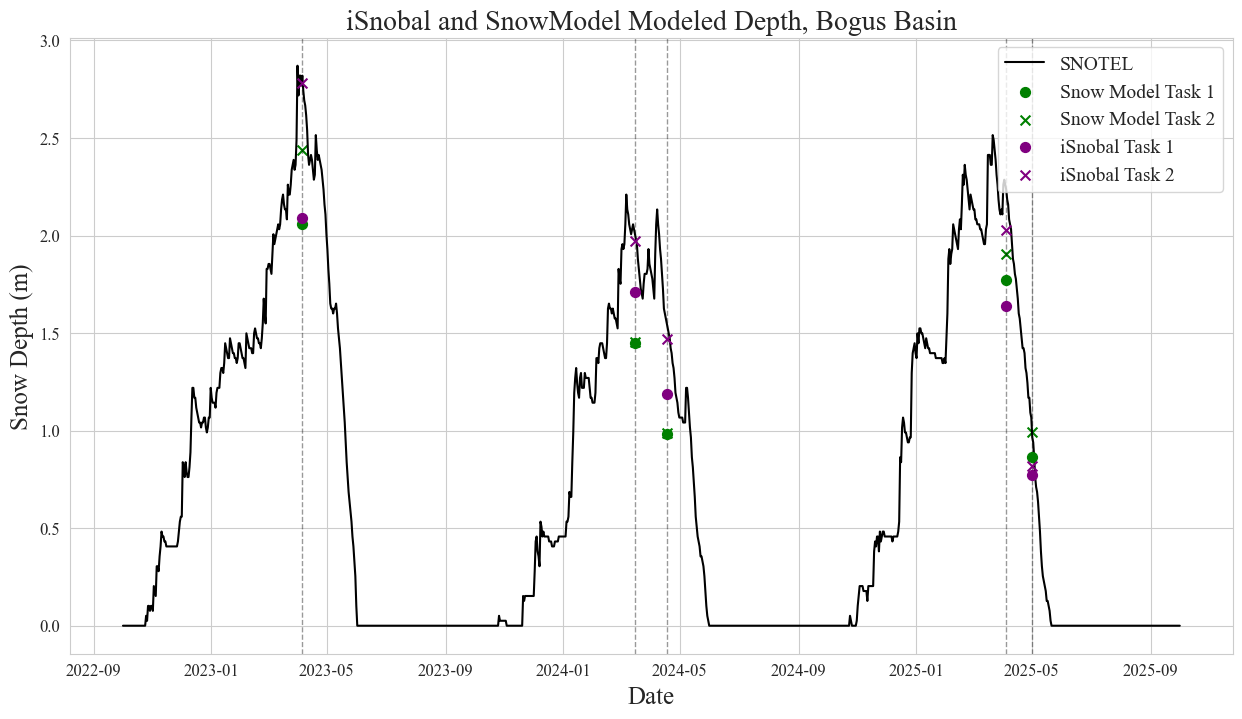

In [47]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = BB_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    BB_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    sm_t1.index,
    sm_t1['BB depth'],
    label='Snow Model Task 1',
    color='green',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    sm_t2.index,
    sm_t2['BB depth'],
    label='Snow Model Task 2',
    color='green',
    marker='x',
    s=50,
    zorder=1
)

ax.scatter(
    isno_t1.index,
    isno_t1['BB depth'],
    label='iSnobal Task 1',
    color='purple',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    isno_t2.index,
    isno_t2['BB depth'],
    label='iSnobal Task 2',
    color='purple',
    marker='x',
    s=50,
    zorder=3
)


ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.set_xlabel('Date', fontsize = 18)
ax.tick_params(axis='both', labelsize=12)
ax.set_title("iSnobal and SnowModel Modeled Depth, Bogus Basin", fontsize=20)
ax.legend(fontsize = 14, loc = 'upper right')

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/SM_BB_snotel.png')

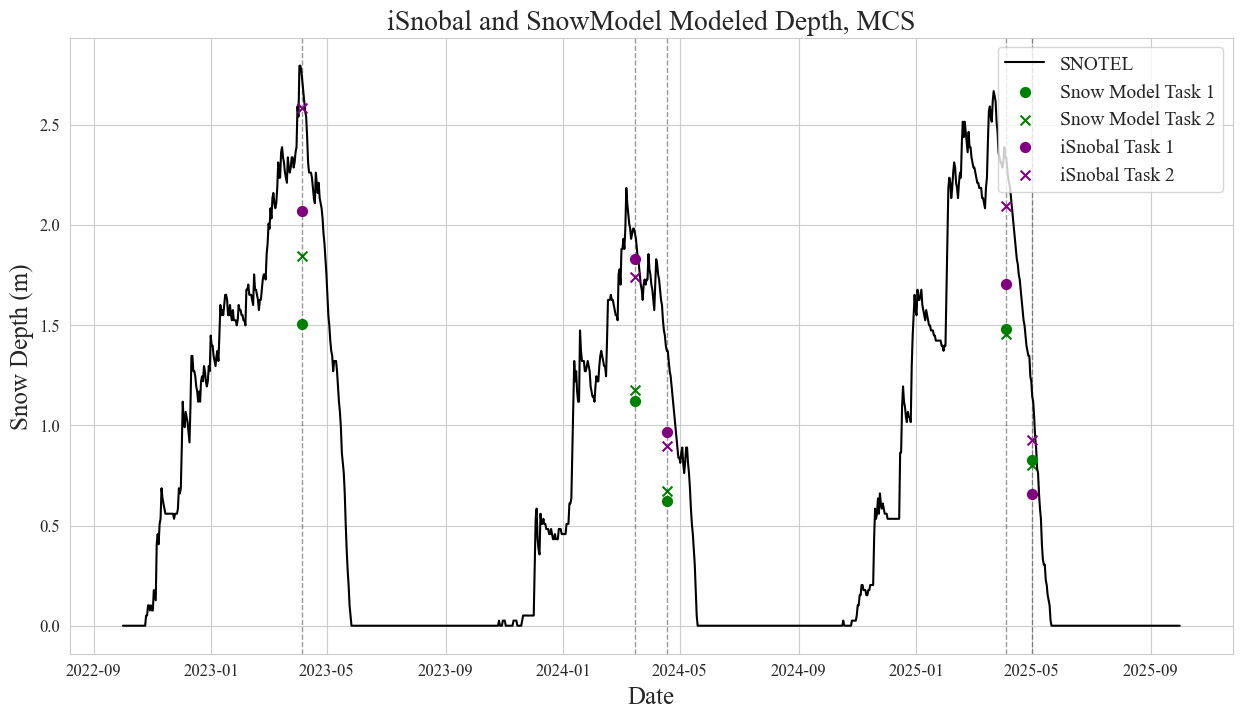

In [48]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = MCS_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    MCS_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    sm_t1.index,
    sm_t1['MCS depth'],
    label='Snow Model Task 1',
    color='green',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    sm_t2.index,
    sm_t2['MCS depth'],
    label='Snow Model Task 2',
    color='green',
    marker='x',
    s=50,
    zorder=1
)

ax.scatter(
    isno_t1.index,
    isno_t1['MCS depth'],
    label='iSnobal Task 1',
    color='purple',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    isno_t2.index,
    isno_t2['MCS depth'],
    label='iSnobal Task 2',
    color='purple',
    marker='x',
    s=50,
    zorder=3
)


ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.set_xlabel('Date', fontsize = 18)
ax.tick_params(axis='both', labelsize=12)
ax.set_title("iSnobal and SnowModel Modeled Depth, MCS", fontsize=20)
ax.legend(fontsize = 14, loc = 'upper right')

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/SM_MCS_snotel.png')

## Same thing with Freeman

In [ ]:
freeman = pd.read_csv("C:/Users/RDCRLSMC/Desktop/Freeman/Freeman.csv", skiprows=11)
freeman.rename(columns={'Unnamed: 0': 'Station'}, inplace=True)
freeman.rename(columns={'Unnamed: 1': 'datetime'}, inplace=True)
freeman["datetime"] = pd.to_datetime(freeman["datetime"], utc=True)
freeman["date"] = freeman["datetime"].dt.date
freeman["time"] = freeman["datetime"].dt.time
freeman["meters"] = freeman["Millimeters"] / 1000


In [ ]:
freeman

In [ ]:
ax.plot(
    dates,
    BB_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)

In [17]:
for key in task1.keys():
    task1_clip = task1[key]['lidar_clip']
    task2_clip = task2[key]['lidar_clip']
    
    MCS = {"Task 1":task1_clip, "Task 2":task2_clip}
    
print(MCS)

{'Task 1': {'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20250501\\outputs/task1/rasters\\HMS_EB_MCS_clip.tif', 'HMS-TI': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20250501\\outputs/task1/rasters\\HMS_TI_MCS_clip.tif', 'iSnobal': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20250501\\outputs/task1/rasters\\iSnobal_MCS_clip.tif', 'LiDAR': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20250501\\outputs/task1/rasters\\LiDAR_MCS_clip.tif', 'SnowModel': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20250501\\outputs/task1/rasters\\SnowModel_MCS_clip.tif'}, 'Task 2': {'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20250501\\outputs/task2/rasters\\HMS_EB_MCS_clip.tif', 'HMS-TI': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20250501\\outputs/task2/rasters\\HMS_TI_MCS_clip.tif', 'iSnobal': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20250501\\outputs/task2/rasters\\iSnobal_MCS_clip.tif', 'LiDAR': 'C:/Users/RDCRL

### Create boxplots that show spread off ALL dates combined

In [72]:
dfs = []

for key in task1.keys():
    task1_clip = task1[key]['lidar_clip']
    task2_clip = task2[key]['lidar_clip']
    
    MCS = {"Task 1":task1_clip, "Task 2":task2_clip}
    
    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    data = src.read(1)
                    mask = (data == -9999)
                    data_masked = np.ma.array(data, mask=mask)
                    flattened = data_masked.compressed()
                    flattened = flattened[flattened < 5]
                    
                    
                    df = pd.DataFrame({
                    "Task":task,
                    "Date":key,
                    "Model": name,        # this column will store model names
                    "Snow Depth": flattened,
                    "measured": name == "lidar"# this column stores raster values
                    })
                    dfs.append(df)
                
    
lidar_domain = pd.concat(dfs, ignore_index=True)    

In [74]:
Task1_lidar = lidar_domain[lidar_domain['Task'] =='Task 1']
Task2_lidar = lidar_domain[lidar_domain['Task'] =='Task 2']

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_28248\2545311265.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])


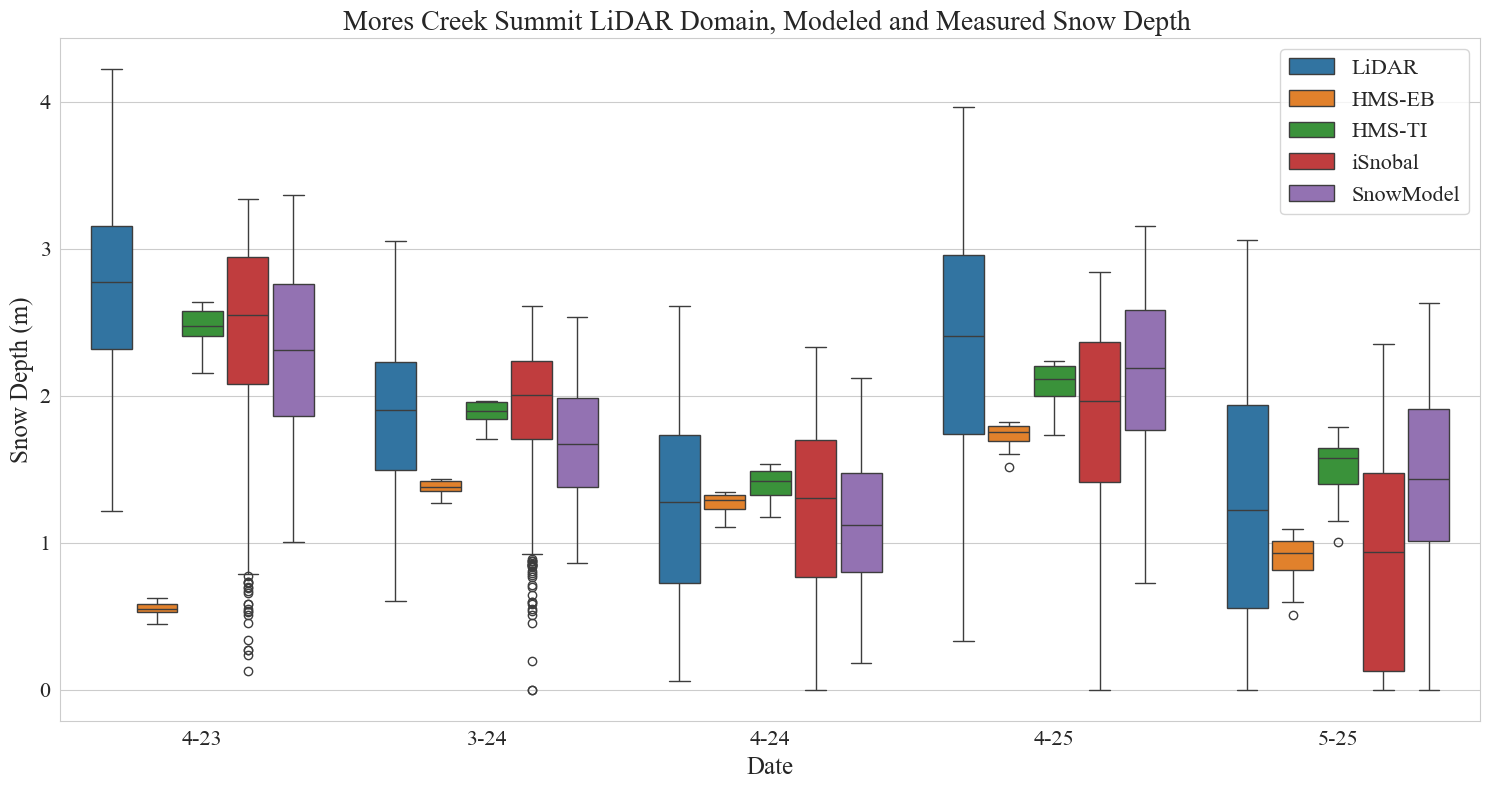

In [71]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(15, 8))

order = ['LiDAR', 'HMS-EB', 'HMS-TI', 'iSnobal', 'SnowModel']

sns.boxplot(
    data=Task1_lidar,
    x = "Date",
    y= "Snow Depth",
    hue = "Model",
    hue_order = order,
    gap = 0.1)


ax.set_xlabel('Date', fontsize = 18)
ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
ax.legend(prop={'size': 16}) # Sets exact font size
ax.set_title("Mores Creek Summit LiDAR Domain, Modeled and Measured Snow Depth ", fontsize=20)



plt.tight_layout()
plt.show() 

In [77]:
dfs = []

for key in task1.keys():
    task1_clip = task1[key]['basin_clip']
    task2_clip = task2[key]['basin_clip']
    
    MCS = {"Task 1":task1_clip, "Task 2":task2_clip}
    
    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    data = src.read(1)
                    mask = (data == -9999)
                    data_masked = np.ma.array(data, mask=mask)
                    flattened = data_masked.compressed()
                    flattened = flattened[flattened < 5]
                    
                    
                    df = pd.DataFrame({
                    "Task":task,
                    "Date":key,
                    "Model": name,        # this column will store model names
                    "Snow Depth": flattened,
                    "measured": name == "lidar"# this column stores raster values
                    })
                    dfs.append(df)
                
    
basin_domain = pd.concat(dfs, ignore_index=True)    

In [78]:
Task1_basin = basin_domain[basin_domain['Task'] =='Task 1']
Task2_basin = basin_domain[basin_domain['Task'] =='Task 2']

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_28248\990108699.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])


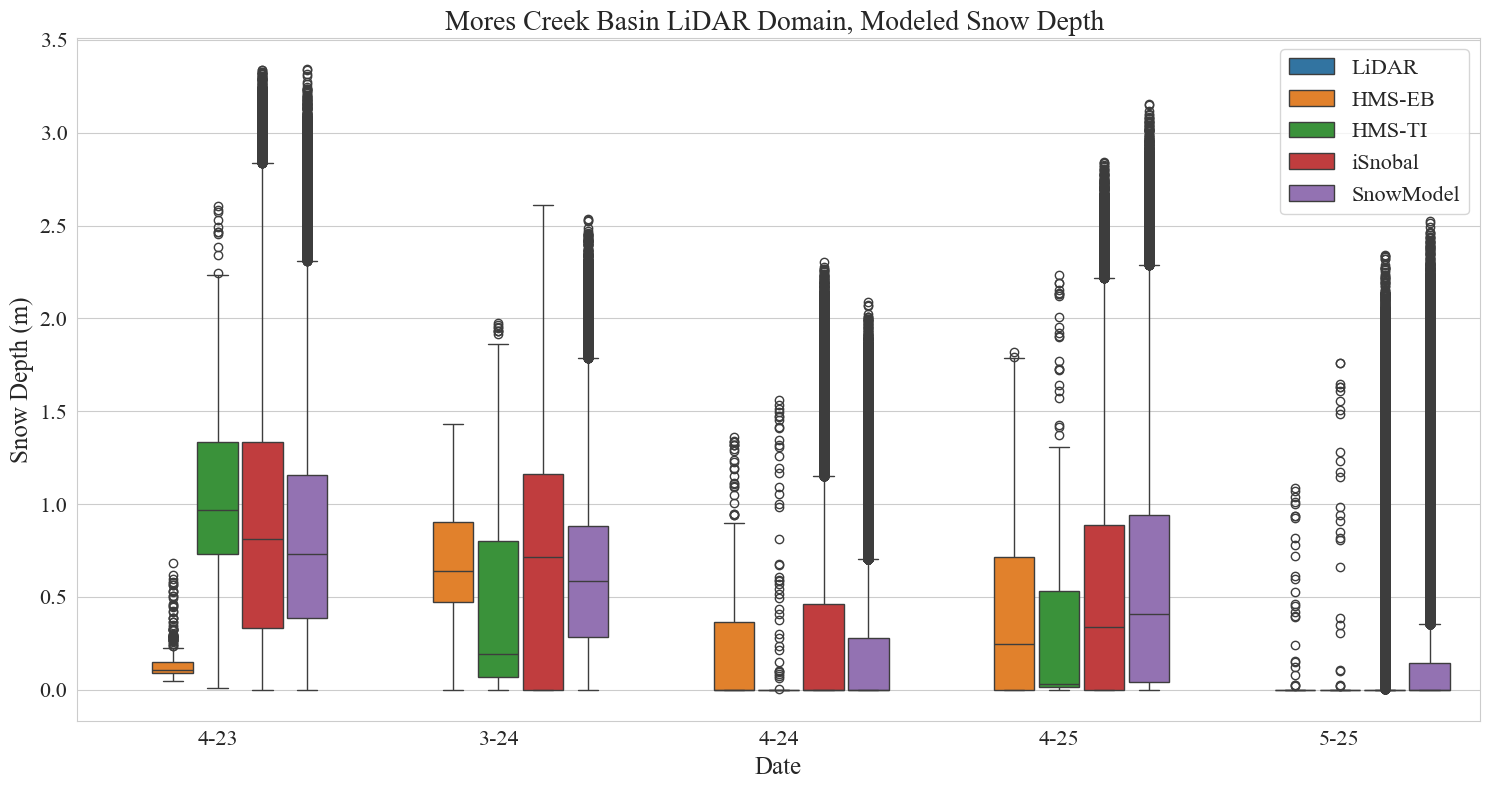

In [79]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(
    data=Task1_basin,
    x = "Date",
    y= "Snow Depth",
    hue = "Model",
    hue_order = order,
    gap = 0.1)


ax.set_xlabel('Date', fontsize = 18)
ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
ax.legend(prop={'size': 16}) # Sets exact font size
ax.set_title("Mores Creek Basin LiDAR Domain, Modeled Snow Depth ", fontsize=20)



plt.tight_layout()
plt.show() 